# Importing The libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

In [3]:
from sklearn.metrics import classification_report

In [4]:
seed=4
tf.random.set_seed(4)

## Load The MNIST data set from keras and Kaagle

In [5]:
data = tf.keras.datasets.mnist

In [6]:
(X_train, Y_train), (X_test, Y_test) = data.load_data()

In [7]:
X_train = np.concatenate((X_train, X_test))
y_train = np.concatenate((Y_train, Y_test))
y_train = y_train.astype(int)

In [8]:
X_train.shape, y_train.shape

((70000, 28, 28), (70000,))

In [9]:
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [10]:
y_train

array([5, 0, 4, ..., 4, 5, 6], shape=(70000,))

In [11]:
len(pd.unique(y_train))

10

In [12]:
test_data = pd.read_csv("test.csv")

In [13]:
test_data = pd.read_csv("test.csv")

# Data Preprocessing

In [14]:
import pandas as pd

valid_data = pd.read_csv("train.csv")

y_validation = valid_data['label'].values
x_validation = valid_data.drop('label', axis=1).values

In [15]:
x_validation

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(42000, 784))

In [16]:
y_validation

array([1, 0, 1, ..., 7, 6, 9], shape=(42000,))

### Reshaping The data

In [17]:
x_train = X_train.reshape(X_train.shape[0], 28,28)
x_validation = x_validation.reshape(x_validation.shape[0],28,28)
x_test = test_data.values.reshape(test_data.shape[0], 28,28)

x_train.shape, y_train.shape, x_validation.shape, y_validation.shape,  x_test.shape

((70000, 28, 28), (70000,), (42000, 28, 28), (42000,), (28000, 28, 28))

### Plot the first sample digit images with their actual label

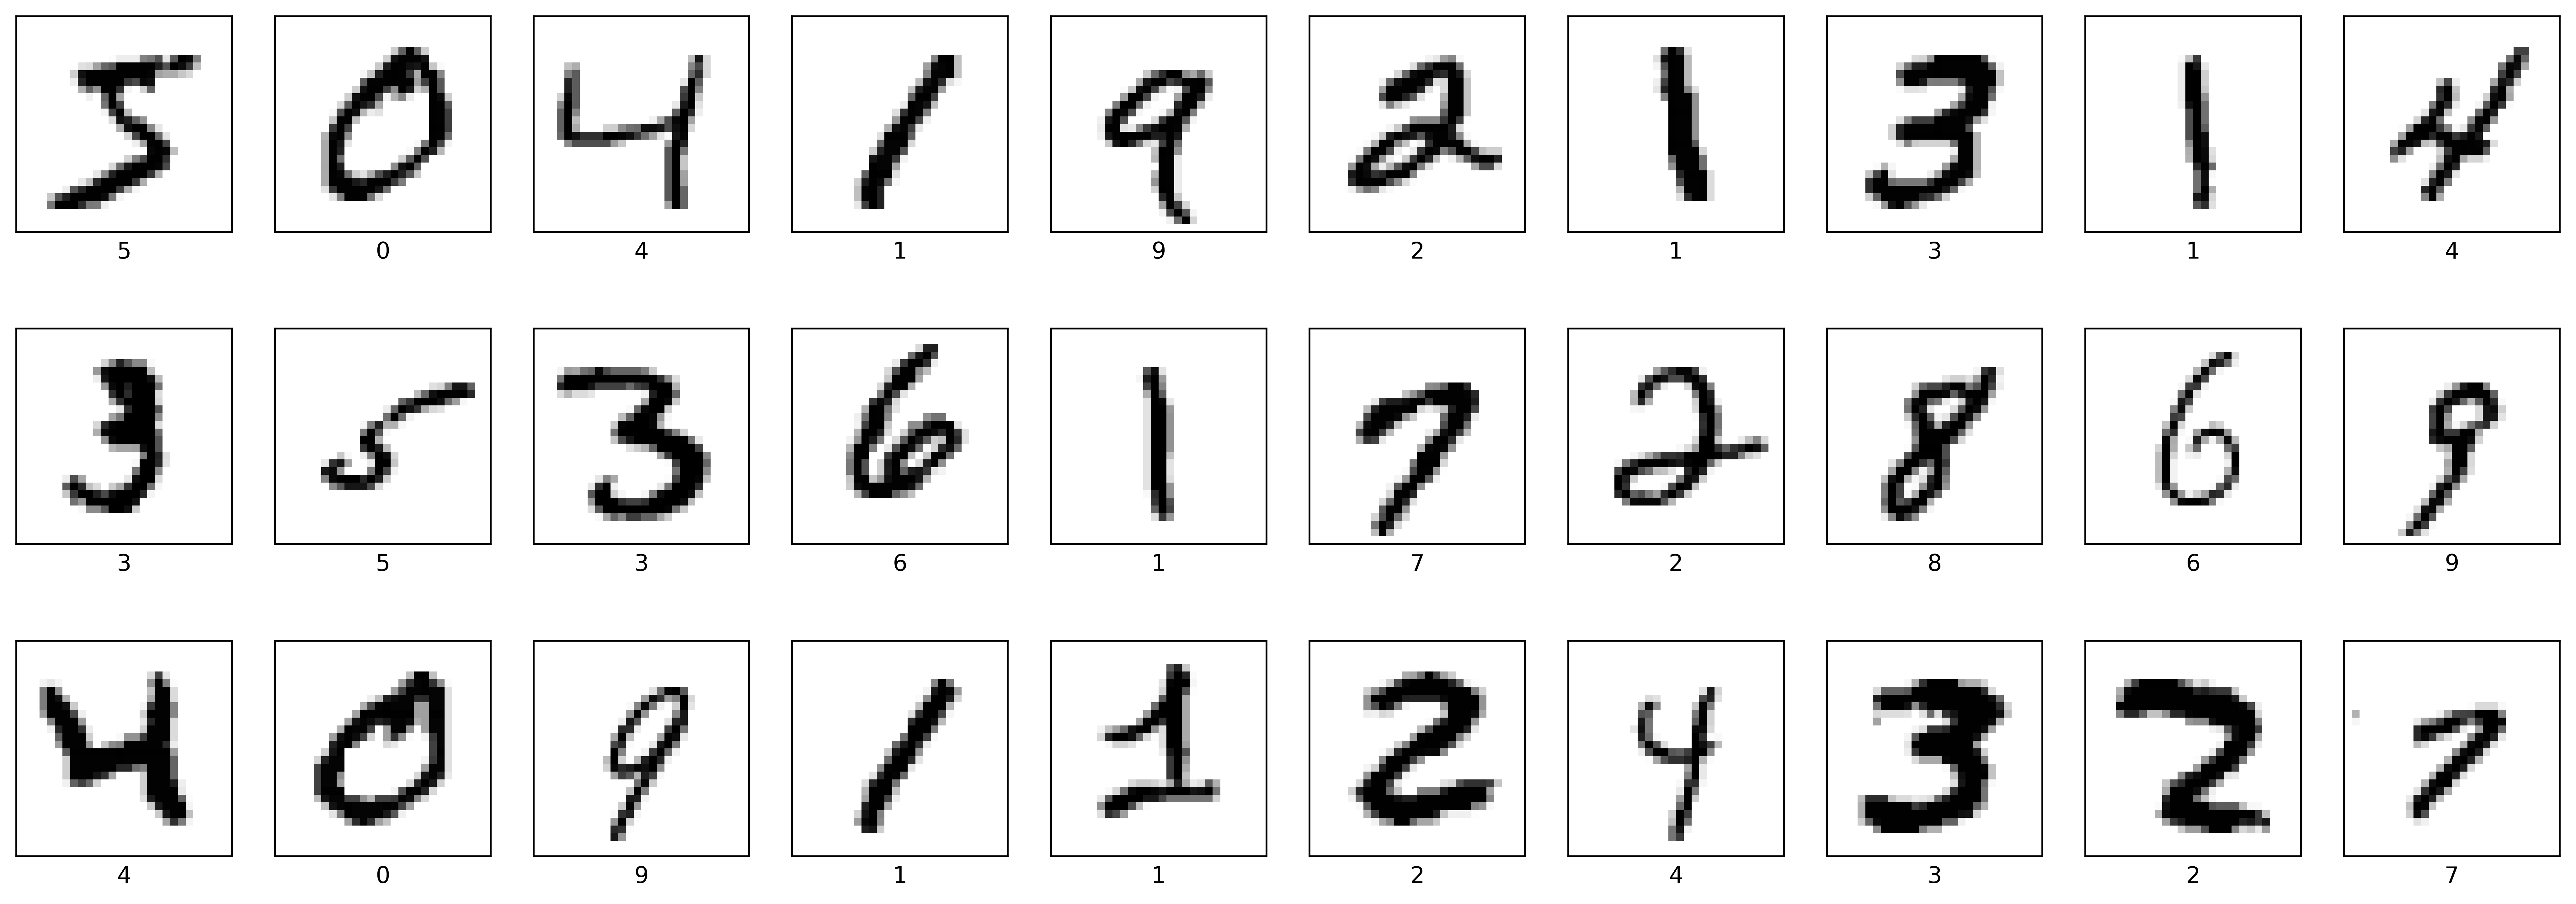

In [18]:
plt.figure(figsize=(20,7), dpi = 523)
for i in range(30):
    plt.subplot(3,10,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(True)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i])                  
plt.show()

### Adding Dimension

In [19]:
x_train = x_train.reshape(-1,28,28,1)
x_valid = x_validation.reshape(-1,28,28,1)
x_test  = x_test.reshape(-1,28,28,1)

print('Train Data shape      :',x_train.shape)
print('Validation Data shape :',x_valid.shape)
print('Test Data shape       :',x_test.shape) 

Train Data shape      : (70000, 28, 28, 1)
Validation Data shape : (42000, 28, 28, 1)
Test Data shape       : (28000, 28, 28, 1)


### Normalization

In [20]:
x_train, x_valid, x_test = x_train / 255, x_valid / 255, x_test / 255

### Encoding the labels

In [21]:
y_train_ = tf.keras.utils.to_categorical(y_train)
y_valid_ = tf.keras.utils.to_categorical(y_validation)

# Model Implementation

In [22]:
batch = 100
epochs = 70

steps_per_epoch = x_train.shape[0]//batch
steps_per_epoch

700

In [23]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(rotation_range=10,zoom_range=0.15)

image_generator = datagen.flow(x_train, y_train_, batch_size=batch, seed=seed,)

In [24]:
print('The Unique digits are :', sorted(pd.unique(y_train)))
n = len(pd.unique(y_train))
print('There are total',n, 'unique digits')

The Unique digits are : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
There are total 10 unique digits


In [25]:
from tensorflow.keras import layers, models
import tensorflow as tf

model = models.Sequential([
    layers.Input(shape=(28,28,1)),

    layers.Conv2D(filters=64, kernel_size=(2,2), activation='relu'),
    layers.Conv2D(64,(4,4),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(filters=64,kernel_size=(2,2),activation='relu'),
    layers.Conv2D(64,(4,4),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),

    layers.Dense(150,activation='relu'),
    layers.Dense(150,activation='relu'),

    layers.Dense(n,activation='softmax')
])

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 27, 27, 64)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 24, 24, 64)          │          65,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 24, 24, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 11, 11, 64)          │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 8, 8, 64)            │          65,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 8, 8, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 4, 4, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 2, 2, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 2, 2, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 150)                 │          76,950 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 150)                 │          22,650 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,510 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 323,958 (1.24 MB)

 Trainable params: 323,446 (1.23 MB)

 Non-trainable params: 512 (2.00 KB)

### Visualizing the model

In [27]:
tf.keras.utils.plot_model(model, show_shapes=True, show_dtype=True, show_layer_names=True, expand_nested=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [28]:
### .et the learning rate = 
lr_rate = 0.0001

In [29]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_accuracy',
                                                  patience = 3,
                                                  min_delta = 1e-4,
                                                  restore_best_weights = True)

In [30]:
import os
os.makedirs("saved_model", exist_ok=True)

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='saved_model/best_model_todate.weights.h5',
    save_best_only=True,
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [31]:
tn = tf.keras.callbacks.TerminateOnNaN()

In [32]:
scheduler = tf.keras.optimizers.schedules.ExponentialDecay(initial_learning_rate = lr_rate,
                                                           decay_steps = steps_per_epoch//4,
                                                           decay_rate= 0.80,
                                                           staircase=True)
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(scheduler)

In [33]:
lr_plateau = tf.keras.callbacks.ReduceLROnPlateau(monitor = 'val_loss',
                                                  factor = 0.1,
                                                  patience = 4, 
                                                  verbose = 3)

###  optimizer and loss function for training

In [34]:
loss_object = tf.keras.losses.CategoricalCrossentropy()

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_rate) 

### model compilation

In [35]:
model.compile(optimizer=optimizer,loss=loss_object, metrics=['accuracy'])

### Training the model

In [36]:
history = model.fit(
    image_generator,
    epochs=epochs,
    validation_data=(x_valid, y_valid_),
    steps_per_epoch=steps_per_epoch,
    callbacks=[lr_plateau, checkpoint_callback, early_stopping, tn]
)

Epoch 1/70
700/700 ━━━━━━━━━━━━━━━━━━━━ 85s 119ms/step - accuracy: 0.9341 - loss: 0.2362 - val_accuracy: 0.9848 - val_loss: 0.0523 - learning_rate: 1.0000e-04
Epoch 2/70
700/700 ━━━━━━━━━━━━━━━━━━━━ 92s 131ms/step - accuracy: 0.9827 - loss: 0.0545 - val_accuracy: 0.9899 - val_loss: 0.0321 - learning_rate: 1.0000e-04
Epoch 3/70
700/700 ━━━━━━━━━━━━━━━━━━━━ 84s 120ms/step - accuracy: 0.9884 - loss: 0.0376 - val_accuracy: 0.9921 - val_loss: 0.0249 - learning_rate: 1.0000e-04
Epoch 4/70
700/700 ━━━━━━━━━━━━━━━━━━━━ 80s 115ms/step - accuracy: 0.9903 - loss: 0.0304 - val_accuracy: 0.9907 - val_loss: 0.0293 - learning_rate: 1.0000e-04
Epoch 5/70
700/700 ━━━━━━━━━━━━━━━━━━━━ 82s 117ms/step - accuracy: 0.9920 - loss: 0.0258 - val_accuracy: 0.9921 - val_loss: 0.0235 - learning_rate: 1.0000e-04
Epoch 6/70
700/700 ━━━━━━━━━━━━━━━━━━━━ 81s 116ms/step - accuracy: 0.9934 - loss: 0.0221 - val_accuracy: 0.9914 - val_loss: 0.0251 - learning_rate: 1.0000e-04


# Model Evaluation

In [37]:
loss, accuracy = model.evaluate(x_valid, y_valid_)
print('The accuracy of model on unknown data is',round((accuracy*100),4),'%')

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.9921 - loss: 0.0249
The accuracy of model on unknown data is 99.2143 %


In [38]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])

### Training Accuracy annd Loss

In [39]:
acc = history_dict['accuracy']
acc

[0.9341142773628235,
 0.9826571345329285,
 0.9884285926818848,
 0.9902856945991516,
 0.9919571280479431,
 0.9933571219444275]

In [40]:
loss = history_dict['loss']  
loss

[0.2361866682767868,
 0.05451541393995285,
 0.037643272429704666,
 0.030371181666851044,
 0.02584833838045597,
 0.022133195772767067]

### Validation Accuracy and Loss

In [41]:
val_acc = history_dict['val_accuracy']  
val_acc

[0.9847618937492371,
 0.9899285435676575,
 0.9921428561210632,
 0.9907380938529968,
 0.9920714497566223,
 0.991357147693634]

In [42]:
val_loss = history_dict['val_loss']
val_loss

[0.052288301289081573,
 0.03209257870912552,
 0.024852585047483444,
 0.029269488528370857,
 0.02352670580148697,
 0.025104494765400887]

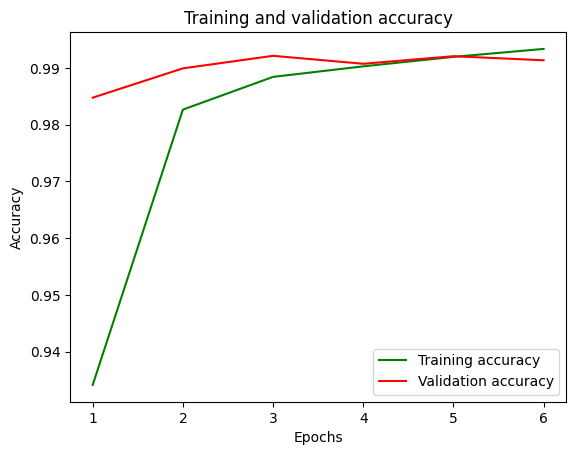

In [43]:
epochs = np.arange(1, len(acc) + 1)
plt.plot(epochs, acc, 'g', label='Training accuracy')                 
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')            
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

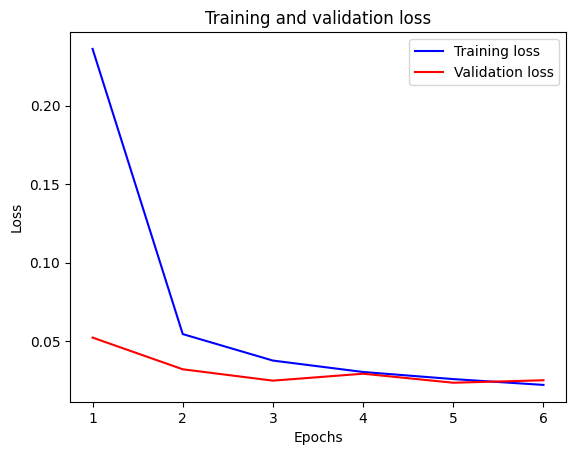

In [44]:
epochs = range(1, len(acc) + 1)                                  
plt.plot(epochs, loss, 'b', label='Training loss')         
plt.plot(epochs, val_loss, 'r', label='Validation loss')     
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Generating the predictions on Validation Set

In [45]:
y_predicted = model.predict(x_valid) 
y_predicted_labels = [np.argmax(i) for i in y_predicted]
print('Predicted Label :',y_predicted_labels[:10])
print('Actual Label    :',y_validation[:10])

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step
Predicted Label : [np.int64(1), np.int64(0), np.int64(1), np.int64(4), np.int64(0), np.int64(0), np.int64(7), np.int64(3), np.int64(5), np.int64(3)]
Actual Label    : [1 0 1 4 0 0 7 3 5 3]


### Confusion Matrix

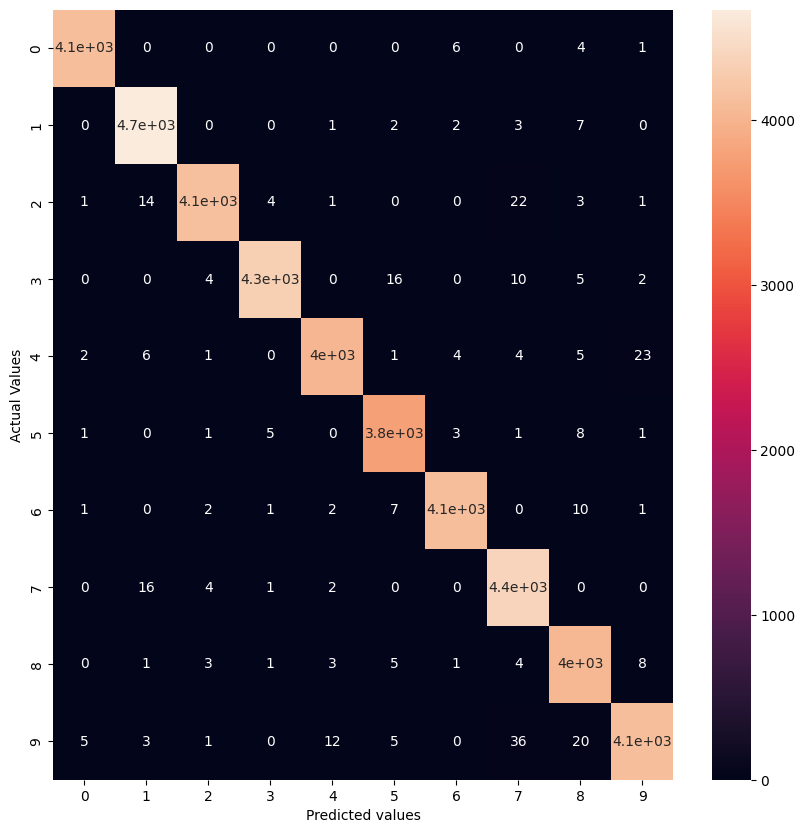

In [46]:
cm = tf.math.confusion_matrix(labels = y_validation, predictions=y_predicted_labels)
plt.figure(figsize = (10,10))
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted values')
plt.ylabel('Actual Values')
plt.show()

In [47]:
print("Classification Report: \n", classification_report(y_validation, y_predicted_labels))

Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4132
           1       0.99      1.00      0.99      4684
           2       1.00      0.99      0.99      4177
           3       1.00      0.99      0.99      4351
           4       0.99      0.99      0.99      4072
           5       0.99      0.99      0.99      3795
           6       1.00      0.99      1.00      4137
           7       0.98      0.99      0.99      4401
           8       0.98      0.99      0.99      4063
           9       0.99      0.98      0.99      4188

    accuracy                           0.99     42000
   macro avg       0.99      0.99      0.99     42000
weighted avg       0.99      0.99      0.99     42000



# Validating the predictions

In [48]:
def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'green'
    else:
        color = 'red'
    plt.xlabel("Pred: {} ({:2.0f}%) \n Truth : {}".format(predicted_label, (100*np.max(predictions_array)),
                                                          true_label), color=color)
    


In [49]:
def plot_value_array(i, predictions_array, true_labels):
    true_label = true_labels[i]
    plt.grid(False)
    plt.xticks(range(10))

    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)
    

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('green')

In [50]:
# for 25 images
num_rows = 5
num_cols = 5
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows), dpi = 523)
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, y_predicted[i], y_validation, x_valid)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, y_predicted[i], y_validation)
plt.tight_layout()
plt.show()

## Inaccurate Predictions

In [51]:
count = 0
wrong_predictions = []
for i in range(len(y_validation)):
    predicted_label = np.argmax(y_predicted[i])
    if predicted_label != y_validation[i]:
        count +=1
        wrong_predictions.append(i)
print('There are',count,'wrong predictions in Validation datasets')
print('Wrong predicted indices :\n',wrong_predictions)

There are 330 wrong predictions in Validation datasets
Wrong predicted indices :
 [95, 125, 516, 614, 639, 641, 644, 799, 897, 1031, 1179, 1224, 1862, 1948, 1979, 2220, 2354, 2453, 2594, 2628, 3038, 3065, 3097, 3136, 3184, 3621, 3672, 3715, 3761, 3960, 3997, 4020, 4040, 4072, 4086, 4092, 4132, 4226, 4400, 4644, 4677, 4790, 4924, 4972, 5017, 5099, 5124, 5389, 5390, 5563, 5583, 5659, 5695, 5747, 5843, 5885, 5990, 6112, 6543, 6624, 6781, 6972, 7008, 7052, 7108, 7138, 7244, 7389, 7426, 7475, 7505, 7525, 7527, 7610, 7725, 8062, 8169, 8260, 8415, 9007, 9062, 9303, 9471, 9472, 9612, 9900, 9992, 9995, 10026, 10544, 10582, 10583, 10710, 10712, 10795, 10910, 11314, 11329, 11367, 11593, 11714, 11942, 12170, 12321, 12520, 12580, 12706, 12919, 12962, 13011, 13044, 13059, 13170, 13309, 13525, 13791, 13928, 14032, 14101, 14284, 14285, 14362, 14434, 15065, 15104, 15121, 15149, 15183, 15281, 15328, 15662, 15846, 15949, 15954, 16124, 16179, 16220, 16301, 16598, 16697, 16859, 17016, 17399, 17819, 17828, 

In [52]:
num_rows = 5
num_cols = 5
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows), dpi = 723)

for ix in range(num_images):
    i = wrong_predictions[ix]
    plt.subplot(num_rows, 2*num_cols, 2*ix+1)
    plot_image(i, y_predicted[i], y_validation, x_valid)
    plt.subplot(num_rows, 2*num_cols, 2*ix+2)
    plot_value_array(i, y_predicted[i], y_validation)
plt.tight_layout()
plt.show()

# Generating Predictions for Test data set

In [53]:
y_predicted = model.predict(X_test) 
y_predicted_labels = [np.argmax(i) for i in y_predicted]
print('Predicted Label :',y_predicted_labels[:10])
print('Actual Label    :',Y_test[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
Predicted Label : [np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(5), np.int64(9)]
Actual Label    : [7 2 1 0 4 1 4 9 5 9]


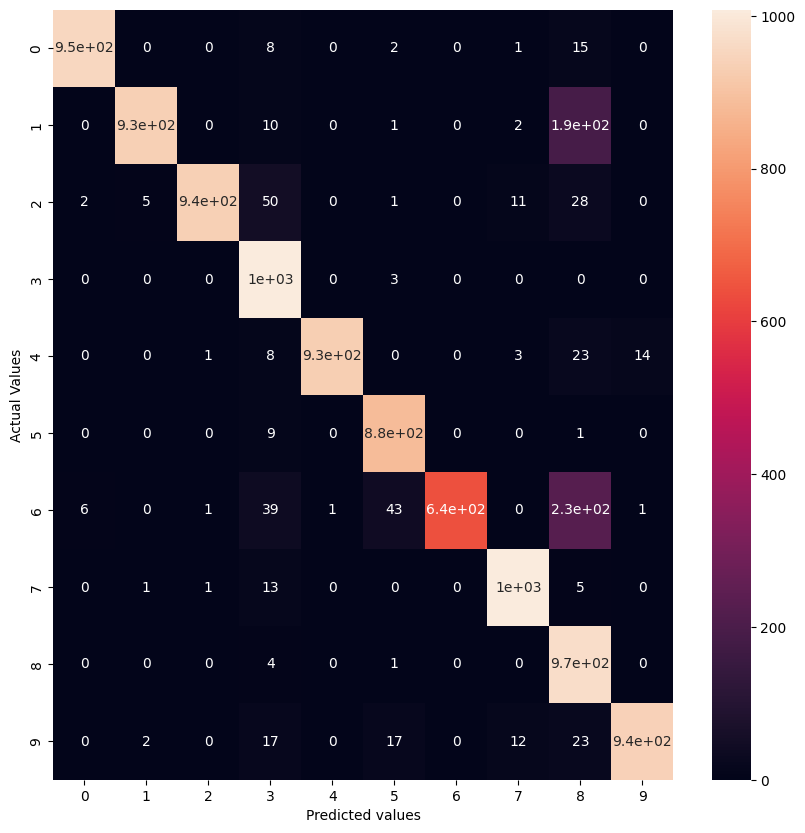

In [54]:
cm = tf.math.confusion_matrix(labels = Y_test, predictions=y_predicted_labels)
plt.figure(figsize = (10,10))
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted values')
plt.ylabel('Actual Values')
plt.show()

In [55]:
print("Classification Report: \n", classification_report(Y_test, y_predicted_labels)) ## 95%accuracy

Classification Report: 
               precision    recall  f1-score   support

           0       0.99      0.97      0.98       980
           1       0.99      0.82      0.90      1135
           2       1.00      0.91      0.95      1032
           3       0.86      1.00      0.93      1010
           4       1.00      0.95      0.97       982
           5       0.93      0.99      0.96       892
           6       1.00      0.67      0.80       958
           7       0.97      0.98      0.98      1028
           8       0.66      0.99      0.79       974
           9       0.98      0.93      0.96      1009

    accuracy                           0.92     10000
   macro avg       0.94      0.92      0.92     10000
weighted avg       0.94      0.92      0.92     10000



In [56]:
num_rows = 5
num_cols = 5
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows), dpi = 523)
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, y_predicted[i], Y_test, X_test)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, y_predicted[i], Y_test)
plt.tight_layout()
plt.show()

### Inaccurate Predictions

In [57]:
count = 0
wrong_predictions = []
for i in range(len(Y_test)):
    predicted_label = np.argmax(y_predicted[i])
    if predicted_label != Y_test[i]:
        count +=1
        wrong_predictions.append(i)
print('There are',count,'wrong predictions in test datasets')
print('Wrong predicted indices :\n',wrong_predictions)

There are 800 wrong predictions in test datasets
Wrong predicted indices :
 [20, 21, 40, 43, 50, 62, 78, 94, 95, 107, 115, 131, 149, 160, 168, 176, 193, 197, 217, 221, 247, 251, 259, 286, 288, 302, 316, 318, 320, 321, 324, 353, 385, 386, 409, 439, 444, 445, 446, 447, 449, 457, 462, 473, 488, 497, 499, 508, 523, 532, 534, 551, 552, 583, 593, 594, 605, 615, 619, 650, 659, 684, 688, 696, 716, 717, 729, 735, 738, 769, 786, 809, 813, 818, 829, 834, 840, 870, 885, 895, 900, 903, 924, 926, 938, 939, 940, 943, 956, 962, 965, 966, 975, 986, 988, 994, 1004, 1014, 1038, 1039, 1040, 1044, 1079, 1099, 1112, 1136, 1138, 1151, 1153, 1161, 1178, 1179, 1181, 1182, 1189, 1196, 1199, 1209, 1212, 1214, 1224, 1226, 1232, 1240, 1247, 1250, 1263, 1292, 1296, 1319, 1326, 1328, 1344, 1357, 1368, 1377, 1393, 1395, 1403, 1404, 1414, 1427, 1430, 1436, 1458, 1459, 1475, 1478, 1500, 1527, 1551, 1554, 1569, 1579, 1587, 1602, 1603, 1609, 1626, 1654, 1657, 1676, 1688, 1691, 1709, 1722, 1725, 1754, 1773, 1790, 1818, 18

In [58]:
num_rows = 5
num_cols = 5
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows), dpi = 723)

for ix in range(num_images):
    i = wrong_predictions[ix]
    plt.subplot(num_rows, 2*num_cols, 2*ix+1)
    plot_image(i, y_predicted[i], Y_test, X_test)
    plt.subplot(num_rows, 2*num_cols, 2*ix+2)
    plot_value_array(i, y_predicted[i], Y_test)
plt.tight_layout()
plt.show()